In [1]:
# 1 — Rebuild the waiting-time base (same rules and 10 terminals as notebooks 07 and 10)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

candidates = [Path.cwd(), *Path.cwd().parents]
BASE = next((p for p in candidates if (p / "data" / "processed").exists()), None)
if BASE is None:
    raise FileNotFoundError(f"data/processed not found from {Path.cwd()} - run from inside the project folder.")
PROC = BASE / "data" / "processed"

calls = pd.read_csv(PROC / "calls_2024_2025.csv", parse_dates=["ts_arrival", "ts_berth", "ts_unberth"])
calls["terminal"] = calls["port"].str.strip() + " | " + calls["terminal_raw"].fillna("").str.strip()
calls["wait_h"] = (calls["ts_berth"] - calls["ts_arrival"]).dt.total_seconds() / 3600
calls["imo"] = pd.to_numeric(calls["imo"], errors="coerce")
calls["file_year_start"] = pd.to_datetime(calls["year"].astype(str) + "-01-01")

lc = calls[calls["navigation"] == "Longo Curso"]
w = lc[lc["ts_arrival"].between("2024-01-01", "2025-12-14 23:59")].copy()
w["arr_year"] = w["ts_arrival"].dt.year
w["month_p"] = w["ts_arrival"].dt.to_period("M")

prof = w.groupby(["terminal", "arr_year"]).agg(
    n=("call_id", "size"), teu=("teu", "mean"), p50=("wait_h", "median"),
    p90=("wait_h", lambda s: s.quantile(0.9)), below_1h=("wait_h", lambda s: (s < 1).mean())).unstack("arr_year")
ok = lambda y: (prof[("n", y)] >= 100) & (prof[("teu", y)] >= 300) & (prof[("below_1h", y)] <= 0.5) \
               & (prof[("p90", y)] / prof[("p50", y)] >= 2)
TERMINALS = prof.index[ok(2024) & ok(2025)].tolist()

uni = w[w["terminal"].isin(TERMINALS)].copy()
monthly = uni.groupby(["terminal", "month_p"]).size().unstack(fill_value=0).astype(float)
dec25 = pd.Period("2025-12", "M")
monthly[dec25] = monthly[dec25] * 31 / 14
low = monthly.lt(0.5 * monthly.drop(columns=[dec25]).median(axis=1), axis=0)
GAP_MONTHS = {(t, m) for t in low.index for m in low.columns if low.loc[t, m]}

mdf = uni[[(t, m) not in GAP_MONTHS for t, m in zip(uni["terminal"], uni["month_p"])]]
mdf = mdf[mdf["wait_h"].between(0, 14 * 24)
          & (mdf["ts_arrival"] >= mdf["file_year_start"] - pd.Timedelta(days=31))].copy()
mdf["month"] = mdf["ts_arrival"].dt.month

src = calls.dropna(subset=["ts_arrival", "ts_berth", "ts_unberth"])
src = src[(src["ts_arrival"] >= "2023-12-01") & src["wait_h"].between(0, 30 * 24)]
parts = []
for t, b in mdf.groupby("terminal"):
    s = src[src["terminal"] == t]
    t0 = b["ts_arrival"].values[:, None]
    arr, ber, unb = (s[c].values[None, :] for c in ["ts_arrival", "ts_berth", "ts_unberth"])
    parts.append(pd.DataFrame({"call_id": b["call_id"].values,
                               "q_waiting": ((arr < t0) & (ber > t0)).sum(axis=1),
                               "q_at_berth": ((ber <= t0) & (unb > t0)).sum(axis=1)}))
mdf = mdf.merge(pd.concat(parts), on="call_id", validate="1:1")

print(f"Terminals: {len(TERMINALS)} | calls by arrival year: {mdf['arr_year'].value_counts().sort_index().to_dict()}")
print("Median wait (h):", mdf.groupby("arr_year")["wait_h"].median().round(1).to_dict())
print("Excluded low-activity months:", sorted((t.split(' | ')[0][:18], str(m)) for t, m in GAP_MONTHS))

Terminals: 10 | calls by arrival year: {2024: 4227, 2025: 4389}
Median wait (h): {2024: 17.6, 2025: 15.2}
Excluded low-activity months: [('Salvador', '2025-08'), ('Salvador', '2025-12'), ('Terminal Portuário', '2024-05'), ('Terminal Portuário', '2024-06')]


In [2]:
# 2 — Question J: does arriving at the weekend cost more waiting?
DAYS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
mdf["ym"] = mdf["ts_arrival"].dt.to_period("M")
mdf["week"] = mdf["ts_arrival"].dt.to_period("W")
mdf["dow"] = mdf["ts_arrival"].dt.dayofweek
mdf["log_w"] = np.log1p(mdf["wait_h"])
g = mdf.groupby(["terminal", "ym"])["log_w"]
mdf["excess"] = (mdf["log_w"] - g.transform("median")).where(g.transform("size") >= 5)

rng = np.random.default_rng(42)
def boot_ci(x, weeks, n_boot=1000):
    d = pd.DataFrame({"x": x, "w": weeks}).dropna()
    groups = [gg["x"].to_numpy() for _, gg in d.groupby("w")]
    k = len(groups)
    meds = [np.median(np.concatenate([groups[j] for j in rng.integers(0, k, k)])) for _ in range(n_boot)]
    return np.percentile(meds, [2.5, 97.5])
pct = lambda v: 100 * (np.exp(v) - 1)

rows = []
for d_, gdf in mdf.groupby("dow"):
    lo, hi = boot_ci(gdf["excess"], gdf["week"])
    rows.append({"day": DAYS[d_], "arrivals": len(gdf), "share_%": 100 * len(gdf) / len(mdf),
                 "median_wait_h": gdf["wait_h"].median(), "vs_same_terminal_month_%": pct(gdf["excess"].median()),
                 "CI_low_%": pct(lo), "CI_high_%": pct(hi)})
print("Wait by day of arrival (vs other ships at the same terminal and month):")
print(pd.DataFrame(rows).set_index("day").round(1).to_string(), "\n")

act = src[src["terminal"].isin(TERMINALS)]
arr_d = act[act["ts_arrival"].between("2024-01-01", "2025-12-14")]["ts_arrival"].dt.dayofweek.value_counts().sort_index()
ber_d = act[act["ts_berth"].between("2024-01-01", "2025-12-14")]["ts_berth"].dt.dayofweek.value_counts().sort_index()
flow = pd.DataFrame({"arrivals": arr_d.values, "berthings": ber_d.values}, index=DAYS)
flow["berthings_per_100_arrivals"] = 100 * flow["berthings"] / flow["arrivals"]
print("All container calls at the 10 terminals: arrivals and berthings by day of week:")
print(flow.round(1).to_string(), "\n")

mdf["weekend"] = mdf["dow"] >= 5
tw = mdf.groupby(["terminal", "weekend"]).agg(n=("call_id", "size"), ex=("excess", "median")).unstack("weekend")
tw_out = pd.DataFrame({"weekday_calls": tw[("n", False)], "weekend_calls": tw[("n", True)],
                       "weekday_vs_peers_%": pct(tw[("ex", False)]), "weekend_vs_peers_%": pct(tw[("ex", True)])})
tw_out["weekend_minus_weekday_pp"] = tw_out["weekend_vs_peers_%"] - tw_out["weekday_vs_peers_%"]
tw_out.index = [t.split(" | ")[0][:18] + " | " + t.split(" | ")[-1][:18] for t in tw_out.index]
print("By terminal: weekend vs weekday arrivals:")
print(tw_out.sort_values("weekend_minus_weekday_pp", ascending=False).round(1).to_string())

Wait by day of arrival (vs other ships at the same terminal and month):
     arrivals  share_%  median_wait_h  vs_same_terminal_month_%  CI_low_%  CI_high_%
day                                                                                 
Mon      1140     13.2           18.0                       5.0       0.0       11.2
Tue      1206     14.0           16.1                      -1.2      -7.2        1.1
Wed      1142     13.3           19.0                       0.6      -3.5        9.9
Thu      1227     14.2           17.2                       9.1       1.6       19.0
Fri      1315     15.3           14.4                      -5.3     -11.1       -0.7
Sat      1250     14.5           14.7                      -1.8      -6.4        0.7
Sun      1336     15.5           15.4                       0.0      -7.9        3.9 

All container calls at the 10 terminals: arrivals and berthings by day of week:
     arrivals  berthings  berthings_per_100_arrivals
Mon      1424       1509    

In [3]:
# 3 — Question F: once a queue builds up, how long does it last?
days = pd.date_range("2024-01-01 12:00", "2025-12-14 12:00", freq="D")
dq_parts = []
for t in TERMINALS:
    s = src[src["terminal"] == t]
    tt = days.values[:, None]
    q = ((s["ts_arrival"].values[None, :] < tt) & (s["ts_berth"].values[None, :] > tt)).sum(axis=1)
    dq_parts.append(pd.DataFrame({"terminal": t, "day": days.normalize(), "queue": q.astype(float)}))
dq = pd.concat(dq_parts, ignore_index=True)
dq["month_p"] = dq["day"].dt.to_period("M")
dq.loc[[(t, m) in GAP_MONTHS for t, m in zip(dq["terminal"], dq["month_p"])], "queue"] = np.nan

def find_episodes(g, q_min, max_gap=1):
    g = g.reset_index(drop=True)
    idx = np.where((g["queue"] >= q_min).to_numpy())[0]
    if len(idx) == 0:
        return []
    spans, start, prev = [], idx[0], idx[0]
    for i in idx[1:]:
        if i - prev <= max_gap + 1:
            prev = i
        else:
            spans.append((start, prev)); start = prev = i
    spans.append((start, prev))
    out = []
    for a, b in spans:
        seg = g["queue"].iloc[a:b + 1].to_numpy()
        peak_i = a + int(np.nanargmax(seg))
        after = g["queue"].iloc[peak_i:].to_numpy()
        clear = np.where(after <= 1)[0]
        out.append({"terminal": g["terminal"].iloc[0], "start": g["day"].iloc[a], "end": g["day"].iloc[b],
                    "days": b - a + 1, "peak_queue": np.nanmax(seg),
                    "days_peak_to_clear": clear[0] if len(clear) else np.nan})
    return out

def episode_summary(q_min):
    eps = pd.DataFrame([e for _, g in dq.groupby("terminal") for e in find_episodes(g, q_min)])
    share = 100 * dq.assign(c=dq["queue"] >= q_min).groupby("terminal")["c"].mean()
    per_t = eps.groupby("terminal").agg(episodes=("days", "size"), median_days=("days", "median"),
                                        p90_days=("days", lambda s: s.quantile(0.9)), longest_days=("days", "max"),
                                        median_peak_queue=("peak_queue", "median"),
                                        median_days_peak_to_clear=("days_peak_to_clear", "median"))
    per_t.insert(0, "days_congested_%", share)
    per_t.index = [t.split(" | ")[0][:18] + " | " + t.split(" | ")[-1][:16] for t in per_t.index]
    return eps, per_t.sort_values("days_congested_%", ascending=False)

eps3, per_t3 = episode_summary(3)
print("Congestion episodes (3+ ships waiting at noon), by terminal, 2024 – 14 Dec 2025:")
print(per_t3.round(1).to_string(), "\n")

print("All episodes pooled — duration in days:",
      eps3["days"].describe(percentiles=[0.5, 0.75, 0.9]).round(1)[["count", "50%", "75%", "90%", "max"]].to_dict())
long_eps = eps3[eps3["days"] >= 7]
print(f"Episodes lasting a week or more: {len(long_eps)} of {len(eps3)}, "
      f"covering {long_eps['days'].sum()} of {eps3['days'].sum()} congested days\n")

eps3["start_month"] = eps3["start"].dt.month
by_m = eps3.groupby("start_month").agg(episodes=("days", "size"), total_days=("days", "sum"))
print("Episodes by month they started (both years):")
print(by_m.T.to_string(), "\n")

cong_days = {(r.terminal, d) for r in eps3.itertuples() for d in pd.date_range(r.start, r.end)}
mdf["in_episode"] = [(t, d) in cong_days for t, d in zip(mdf["terminal"], mdf["ts_arrival"].dt.normalize())]
print("Calls arriving during an episode vs other calls:")
print(mdf.groupby("in_episode").agg(calls=("call_id", "size"), median_wait_h=("wait_h", "median"),
                                    p90_wait_h=("wait_h", lambda s: s.quantile(0.9))).round(1).to_string(), "\n")

eps5, per_t5 = episode_summary(5)
print("Sensitivity — threshold of 5 ships waiting:")
print(per_t5[["days_congested_%", "episodes", "median_days", "p90_days", "longest_days",
              "median_days_peak_to_clear"]].round(1).to_string())

Congestion episodes (3+ ships waiting at noon), by terminal, 2024 – 14 Dec 2025:
                                       days_congested_%  episodes  median_days  p90_days  longest_days  median_peak_queue  median_days_peak_to_clear
Santos | Cais da BTP (SSZ                          55.0        54          3.0      20.0            86                4.0                        3.0
Santos | Cais da Santos B                          52.9        57          3.0      11.6            83                4.0                        3.0
Paranaguá | TCP                                    51.3        44          3.0      26.4            65                4.0                        4.0
DP World Santos | DP World Santos                  45.8        49          3.0      26.2            62                4.0                        4.0
Portonave - Termin | Portonave - Term              38.7        53          3.0      11.8            75                4.0                        4.0
Rio Grande | Cais Tecon R

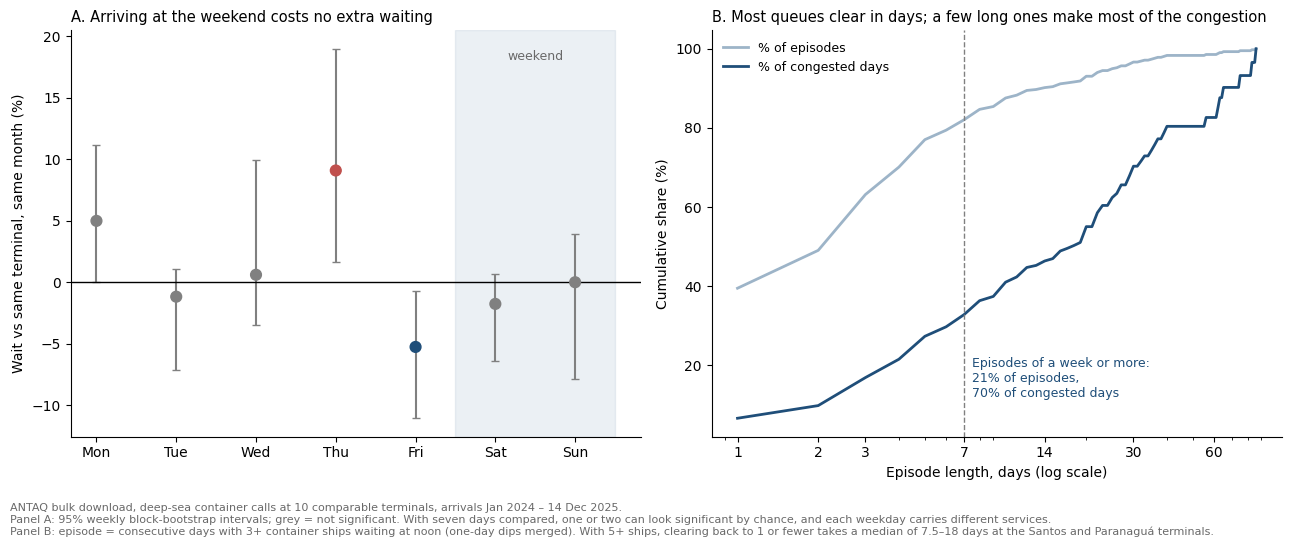

In [4]:
# 4 — Figure (fig16): no weekend penalty; congestion is made by a few long episodes
FIG_DIR = BASE / "outputs" / "figures"
jt = pd.DataFrame(rows).set_index("day")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Panel A — wait by day of arrival
xx = np.arange(len(jt))
est = jt["vs_same_terminal_month_%"]
col = np.where(jt["CI_low_%"] > 0, "#c0504d", np.where(jt["CI_high_%"] < 0, "#1f4e79", "grey"))
ax1.errorbar(xx, est, yerr=[est - jt["CI_low_%"], jt["CI_high_%"] - est], fmt="none", ecolor="grey", capsize=3)
ax1.scatter(xx, est, color=col, s=60, zorder=3)
ax1.axhline(0, color="black", lw=1)
ax1.axvspan(4.5, 6.5, color="#9db4c8", alpha=0.2)
ax1.text(5.5, jt["CI_high_%"].max() * 0.95, "weekend", ha="center", fontsize=9, color="dimgrey")
ax1.set_xticks(xx, jt.index)
ax1.set_ylabel("Wait vs same terminal, same month (%)")
ax1.set_title("A. Arriving at the weekend costs no extra waiting", loc="left", fontsize=10.5)

# Panel B — cumulative share of episodes and of congested days, by episode length
d = eps3["days"].to_numpy()
L = np.arange(1, d.max() + 1)
ax2.plot(L, [100 * (d <= l).mean() for l in L], color="#9db4c8", lw=2, label="% of episodes")
ax2.plot(L, [100 * d[d <= l].sum() / d.sum() for l in L], color="#1f4e79", lw=2, label="% of congested days")
ax2.axvline(7, color="grey", ls="--", lw=1)
share_eps = 100 * (d >= 7).mean()
share_days = 100 * d[d >= 7].sum() / d.sum()
ax2.text(7.5, 12, f"Episodes of a week or more:\n{share_eps:.0f}% of episodes,\n{share_days:.0f}% of congested days",
         fontsize=9, color="#1f4e79")
ax2.set_xscale("log")
ax2.set_xticks([1, 2, 3, 7, 14, 30, 60])
ax2.set_xticklabels(["1", "2", "3", "7", "14", "30", "60"])
ax2.set_xlabel("Episode length, days (log scale)")
ax2.set_ylabel("Cumulative share (%)")
ax2.set_title("B. Most queues clear in days; a few long ones make most of the congestion", loc="left", fontsize=10.5)
ax2.legend(frameon=False, fontsize=9, loc="upper left")

for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)

fig.text(0.01, -0.08,
         "ANTAQ bulk download, deep-sea container calls at 10 comparable terminals, arrivals Jan 2024 – 14 Dec 2025.\n"
         "Panel A: 95% weekly block-bootstrap intervals; grey = not significant. With seven days compared, one or two can "
         "look significant by chance, and each weekday carries different services.\n"
         "Panel B: episode = consecutive days with 3+ container ships waiting at noon (one-day dips merged). With 5+ ships, "
         "clearing back to 1 or fewer takes a median of 7.5–18 days at the Santos and Paranaguá terminals.",
         fontsize=8, color="dimgrey")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig16_weekday_congestion.png", dpi=150, bbox_inches="tight")
plt.show()

## What this notebook answers

Same base as notebooks 07 and 10: deep-sea container calls at 10 comparable terminals, arrivals January 2024 to 14 December 2025.

**Does arriving at the weekend cost more waiting?** No.

- Ships arriving on Saturday (−1.8%, 95% CI −6.4% to +0.7%) or Sunday (0.0%, −7.9% to +3.9%) wait the same as other ships at the same terminal and month.
- Terminals berth ships at the same pace every day: 97–106 berthings per 100 arrivals on each day of the week, with at most a small Sunday dip made up on Monday.
- Thursday (+9%) and Friday (−5%) come out slightly different, but with seven days compared one or two can do so by chance, and each weekday carries different services.
- By terminal, the two Santos terminals (BTP, Santos Brasil) look slightly worse at weekends and Itapoá and TCP slightly better. These are indicative only: no intervals and 150–450 weekend arrivals per terminal.

**How long does congestion last once a queue builds up?** Most episodes are short; a few long ones make most of the congestion.

- **At the big Santos and Paranaguá terminals, three ships waiting is the normal state** (more than half of all days), so a threshold of five ships describes real congestion better there.
- **With five or more ships waiting, clearing back to one or none takes a median of 7.5–18 days** at the Santos and Paranaguá terminals (DP World Santos 18, BTP 15, Santos Brasil 8, TCP 7.5). Itapoá reaches five ships waiting on under 2% of days.
- **One episode in five lasts a week or more, and those make up 70% of all congested days** (threshold of three ships: 86 of 418 episodes, 1,757 of 2,500 days). The median episode lasts three days.
- **Long episodes start mostly between June and October,** with August the heaviest month, consistent with the August peak in notebook 07.
- Ships arriving during an episode wait about four times longer (median 32 h vs 8 h).

## Limitations

1. **The queue is counted once a day, at noon,** so queues that build and clear within hours are not seen.
2. **A fixed threshold** treats terminals with different numbers of berths alike; results are shown for three and five ships waiting.
3. **Episodes are not split by year.** The longest ones most likely fall in 2024, the year of heavy congestion at DP World Santos and Portonave.
4. **Weekday comparisons mix day and service,** because weekly services arrive on fixed days.